In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/workspace/feature-circuits/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/workspace/feature-circuits/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/workspace/feature-circuits/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_lo

In [2]:
sae_effects = "/workspace/feature-circuits/circuits/saes_rc.pt"
components_effects = "/workspace/feature-circuits/circuits/components_rc.pt"

#let's use for now the file 2 as the file 1 with different parameters, make a dummy file 2
THRESHOLD_COMPONENT = 0.1
CONSIDERING_ABS_VAL = False
THRESHOLD_SAE = 0.1
UNITE_RESC = False #Unite resc and treat it as a node

In [3]:
with open(sae_effects, 'rb') as infile:
    sae_nodes = torch.load(infile)['nodes']

for n, v in sae_nodes.items():
    print(n)
    print(v.act.shape)

/workspace/feature-circuits/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


embed
torch.Size([6, 32768])
attn_0
torch.Size([6, 32768])
mlp_0
torch.Size([6, 32768])
resid_0
torch.Size([6, 32768])
attn_1
torch.Size([6, 32768])
mlp_1
torch.Size([6, 32768])
resid_1
torch.Size([6, 32768])
attn_2
torch.Size([6, 32768])
mlp_2
torch.Size([6, 32768])
resid_2
torch.Size([6, 32768])
attn_3
torch.Size([6, 32768])
mlp_3
torch.Size([6, 32768])
resid_3
torch.Size([6, 32768])
attn_4
torch.Size([6, 32768])
mlp_4
torch.Size([6, 32768])
resid_4
torch.Size([6, 32768])
attn_5
torch.Size([6, 32768])
mlp_5
torch.Size([6, 32768])
resid_5
torch.Size([6, 32768])


In [4]:
with open(components_effects, 'rb') as infile:
    components_nodes = torch.load(infile)['nodes']
    
for n, v in components_nodes.items():
    print(n)
    print(v.act.shape)

embed
torch.Size([6])
attn_0
torch.Size([6])
mlp_0
torch.Size([6])
resid_0
torch.Size([6])
attn_1
torch.Size([6])
mlp_1
torch.Size([6])
resid_1
torch.Size([6])
attn_2
torch.Size([6])
mlp_2
torch.Size([6])
resid_2
torch.Size([6])
attn_3
torch.Size([6])
mlp_3
torch.Size([6])
resid_3
torch.Size([6])
attn_4
torch.Size([6])
mlp_4
torch.Size([6])
resid_4
torch.Size([6])
attn_5
torch.Size([6])
mlp_5
torch.Size([6])
resid_5
torch.Size([6])


In [5]:
#plot a graph where on the x I have the potency of components, and on the y I have the sum potency of the saes which are over the threshold
sum_potency_sae = {}
for n, v in sae_nodes.items():
    #put at value 0 the components that are below the threshold
    if CONSIDERING_ABS_VAL:
        v.resc[v.resc.abs() < THRESHOLD_SAE] = 0
        v.act[v.act.abs() < THRESHOLD_SAE] = 0
    else:
        v.resc[v.resc < THRESHOLD_SAE] = 0
        v.act[v.act < THRESHOLD_SAE] = 0
        
    if UNITE_RESC:
        sum_potency_sae[n] = torch.add(v.act.sum(dim=1), v.resc.sum(dim=1))
    else:
        sum_potency_sae[n] = v.act.sum(dim=1)

In [6]:
#plot a graph where on the x I have the potency of components, and on the y I have the number of SAEs over the threshold
number_potent_saes = {}
for n, v in sae_nodes.items():
    #count the number of components with absolute value > threshold
    if CONSIDERING_ABS_VAL:
        v.resc[v.resc.abs() < THRESHOLD_SAE] = 0
        v.resc[v.resc.abs() > 0] = 1
    else:
        v.resc[v.resc < THRESHOLD_SAE] = 0
        v.resc[v.resc > 0] = 1
        
    print((v.act.abs() > THRESHOLD_SAE).sum(dim=1))
    if UNITE_RESC:
        number_potent_saes[n] =  torch.add((v.act.abs() > THRESHOLD_SAE).sum(dim=1), v.resc.squeeze())
    else:
        number_potent_saes[n] = (v.act.abs() > THRESHOLD_SAE).sum(dim=1)
    print(number_potent_saes[n])
    print(number_potent_saes[n].shape)

tensor([ 0, 12,  0,  0,  0,  0], device='cuda:0')
tensor([ 0, 12,  0,  0,  0,  0], device='cuda:0')
torch.Size([6])
tensor([0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([0, 0, 0, 0, 0, 0], device='cuda:0')
torch.Size([6])
tensor([0, 8, 0, 0, 0, 0], device='cuda:0')
tensor([0, 8, 0, 0, 0, 0], device='cuda:0')
torch.Size([6])
tensor([0, 8, 0, 0, 0, 0], device='cuda:0')
tensor([0, 8, 0, 0, 0, 0], device='cuda:0')
torch.Size([6])
tensor([0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([0, 0, 0, 0, 0, 0], device='cuda:0')
torch.Size([6])
tensor([0, 2, 0, 0, 0, 0], device='cuda:0')
tensor([0, 2, 0, 0, 0, 0], device='cuda:0')
torch.Size([6])
tensor([0, 5, 0, 0, 0, 0], device='cuda:0')
tensor([0, 5, 0, 0, 0, 0], device='cuda:0')
torch.Size([6])
tensor([0, 0, 1, 0, 0, 0], device='cuda:0')
tensor([0, 0, 1, 0, 0, 0], device='cuda:0')
torch.Size([6])
tensor([0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([0, 0, 0, 0, 0, 0], device='cuda:0')
torch.Size([6])
tensor([0, 2, 1, 0, 0, 0], device='cuda:0')
tensor([

## Plotting greater than task fake

#### potency of saes with absolute value and treating resc as a component for all

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7

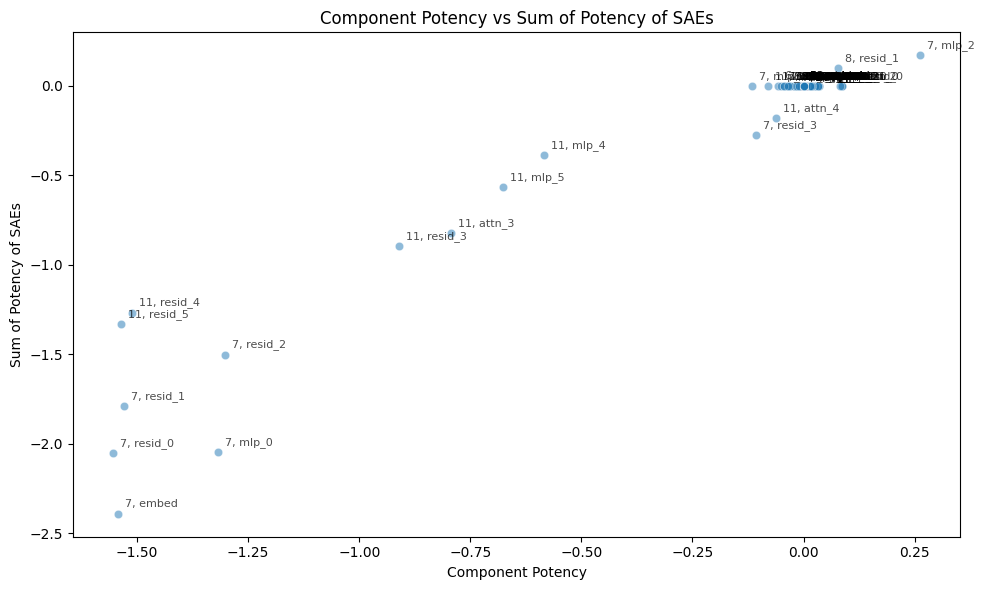

In [19]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    print(indices)

    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### potency of saes with absolute value and treating resc as a component for selected

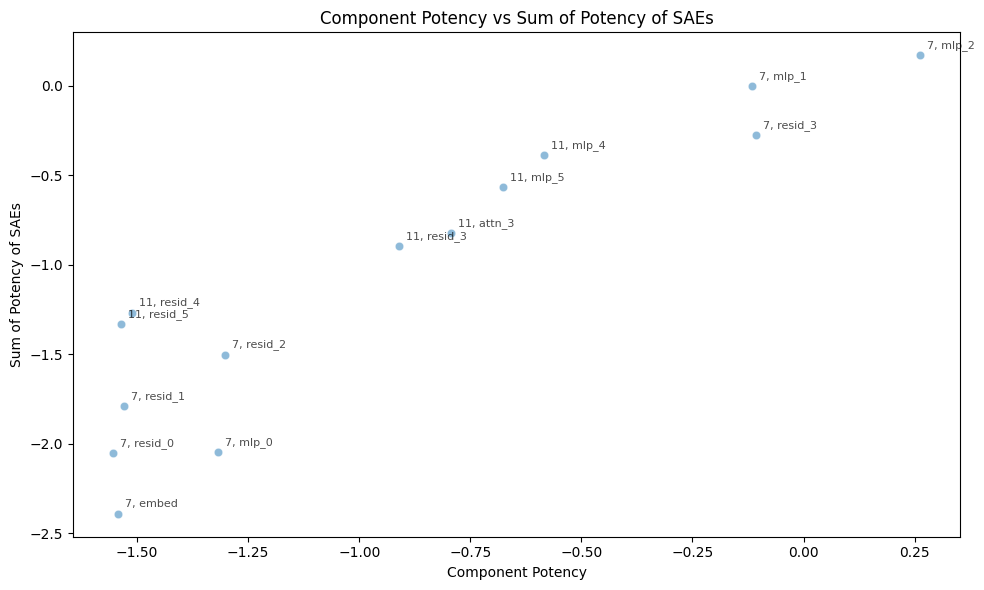

In [20]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and treating resc as a component for all 

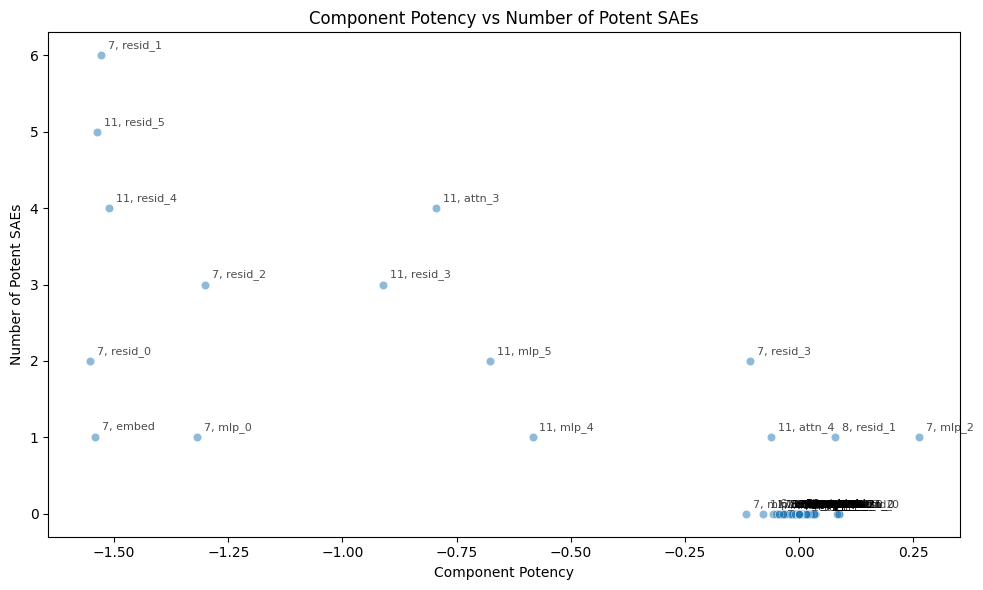

In [20]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and treating resc as a component for selected

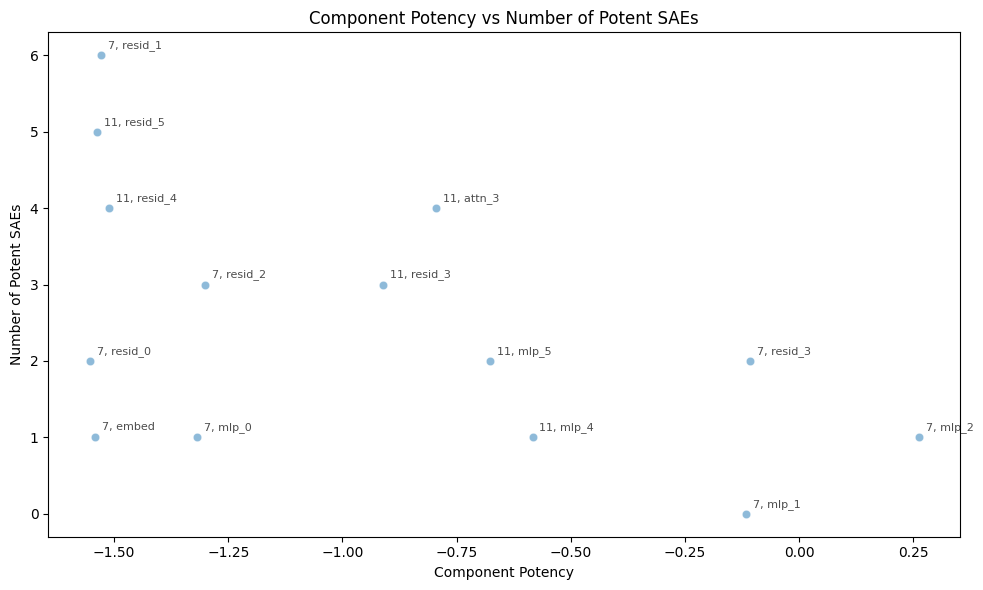

In [21]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and without treating resc as a component for all

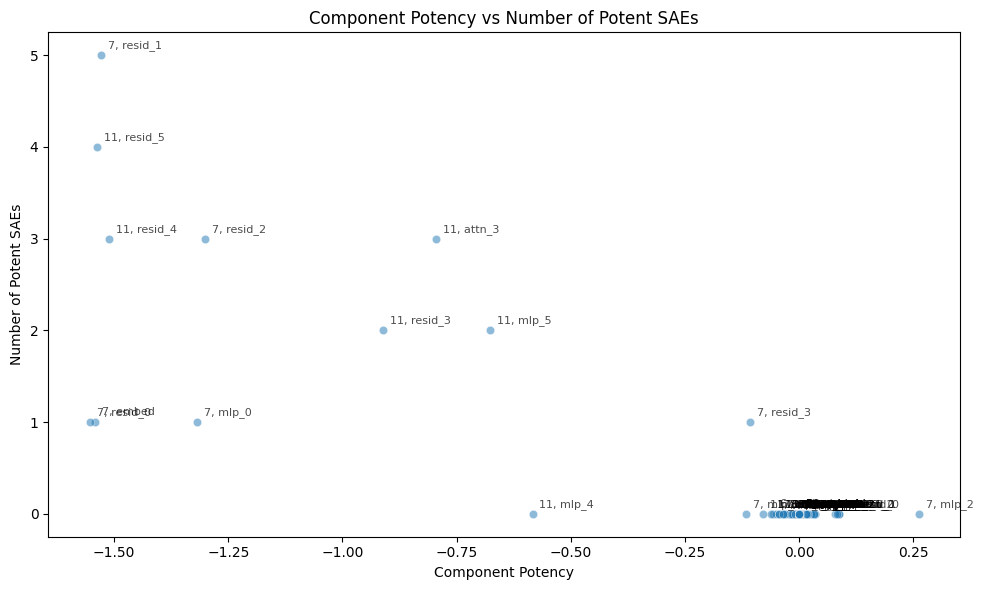

In [9]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold    
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and without treating resc as a component for selected

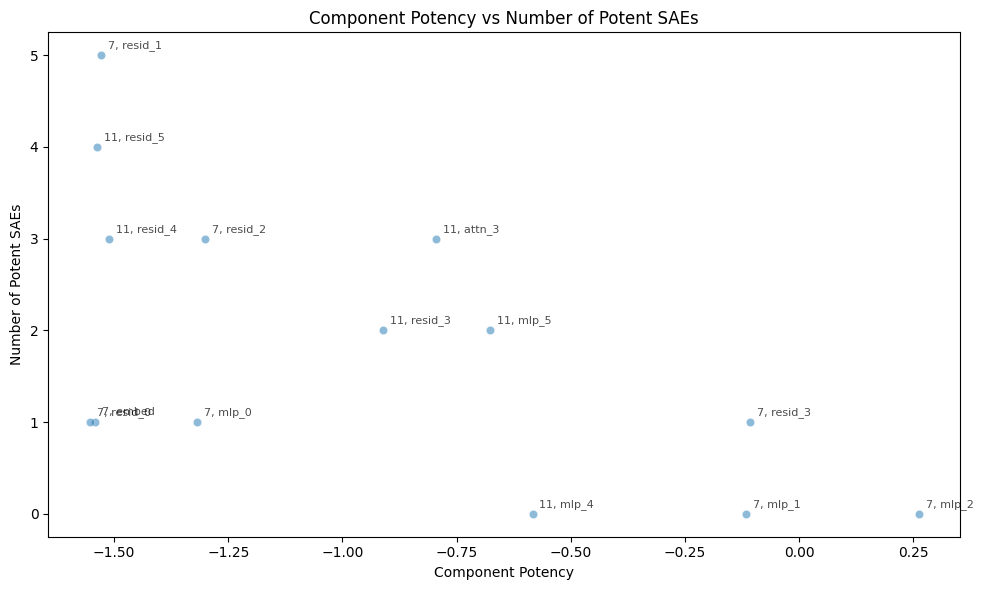

In [7]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### component vs potency of saes without treating resc as a node and using absolute value for all

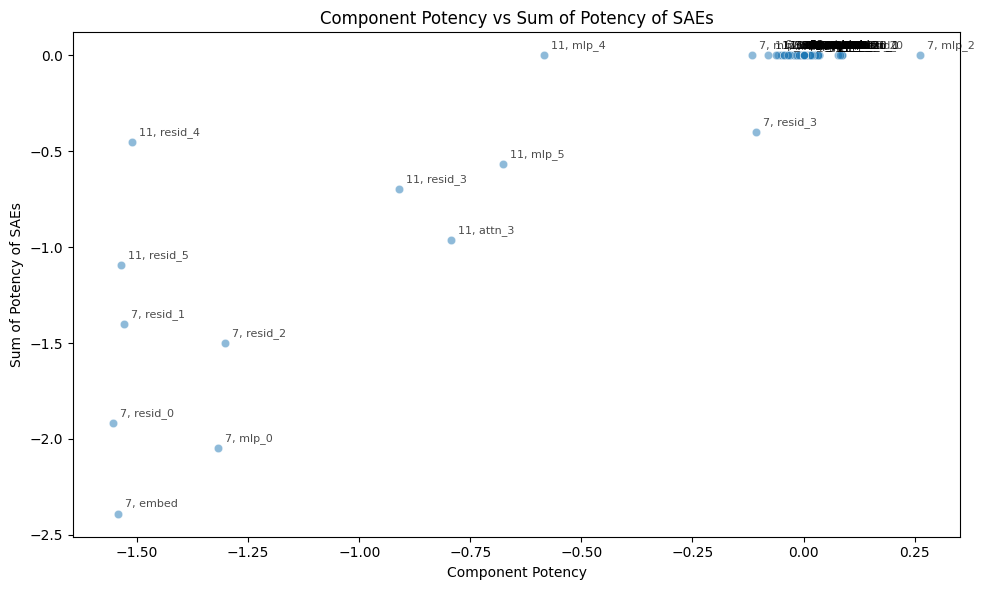

In [11]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### component vs potency of saes without treating resc as a node and using absolute value for selected

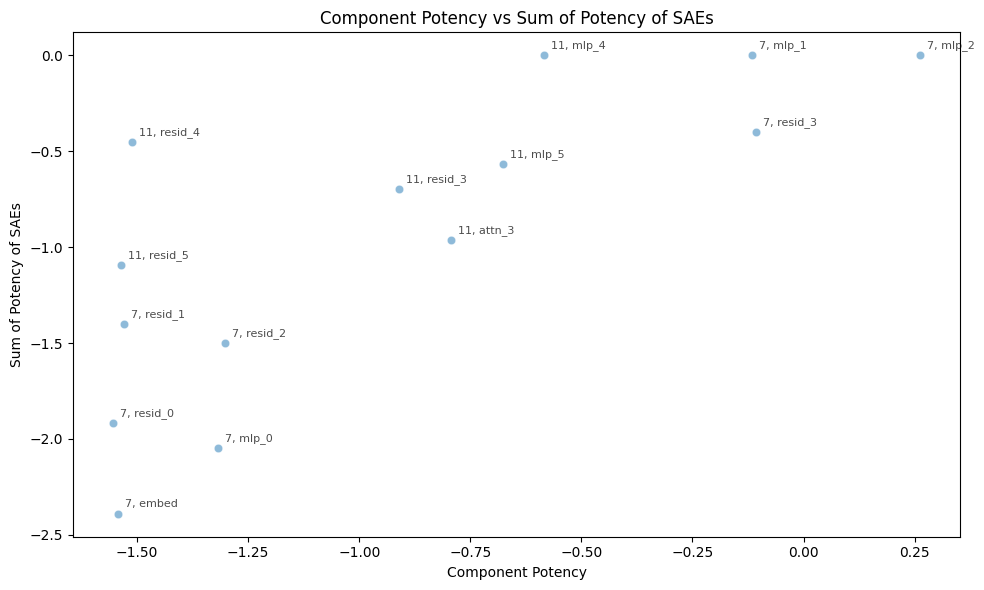

In [9]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

## Plotting greater than task

#### potency of saes with absolute value and treating resc as a component for all

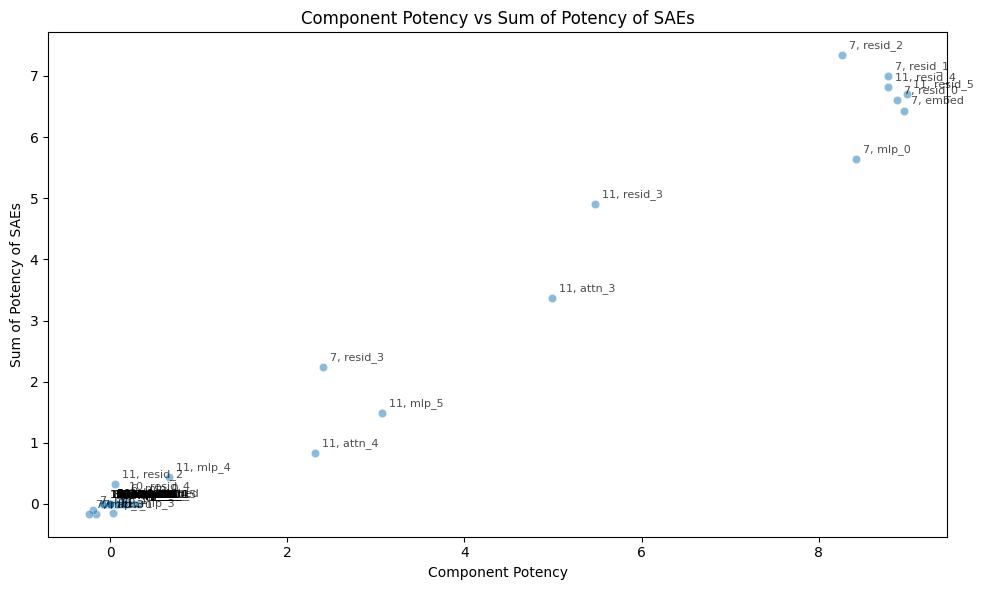

In [8]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

 #### potency of saes with absolute value and treating resc as a component for selected

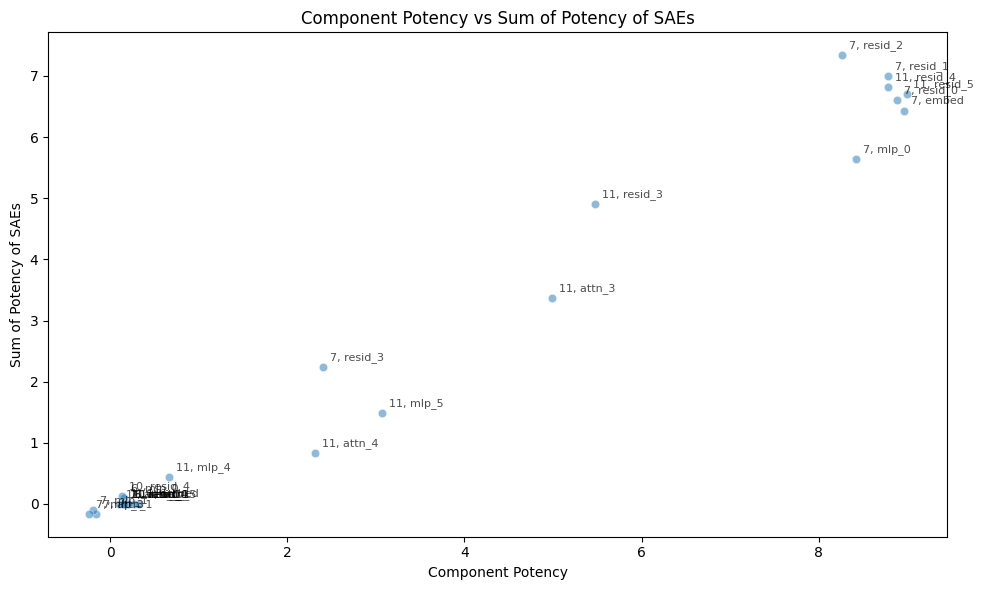

In [17]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and treating resc as a component for all

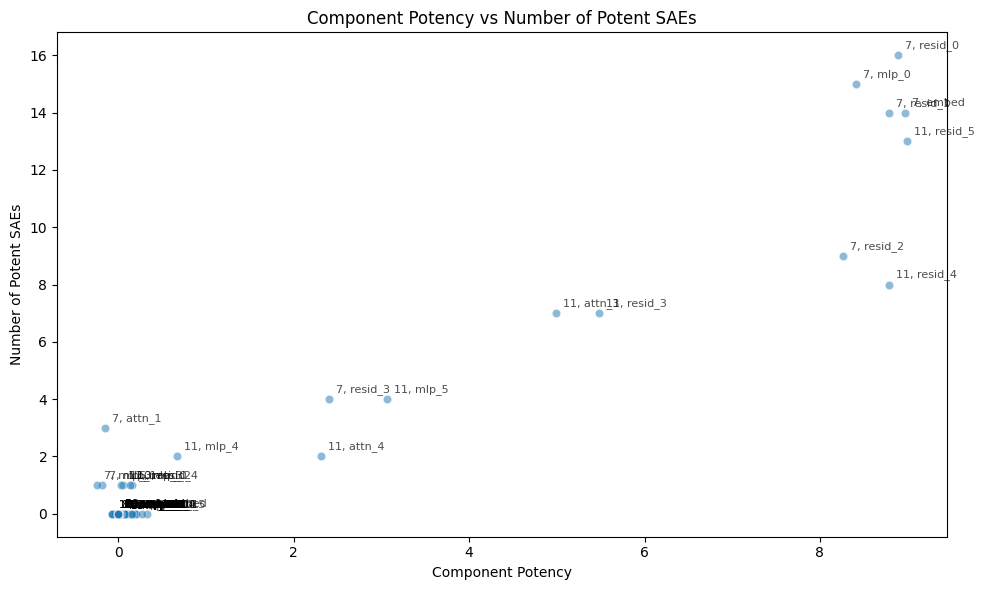

In [10]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and treating resc as a component for selected

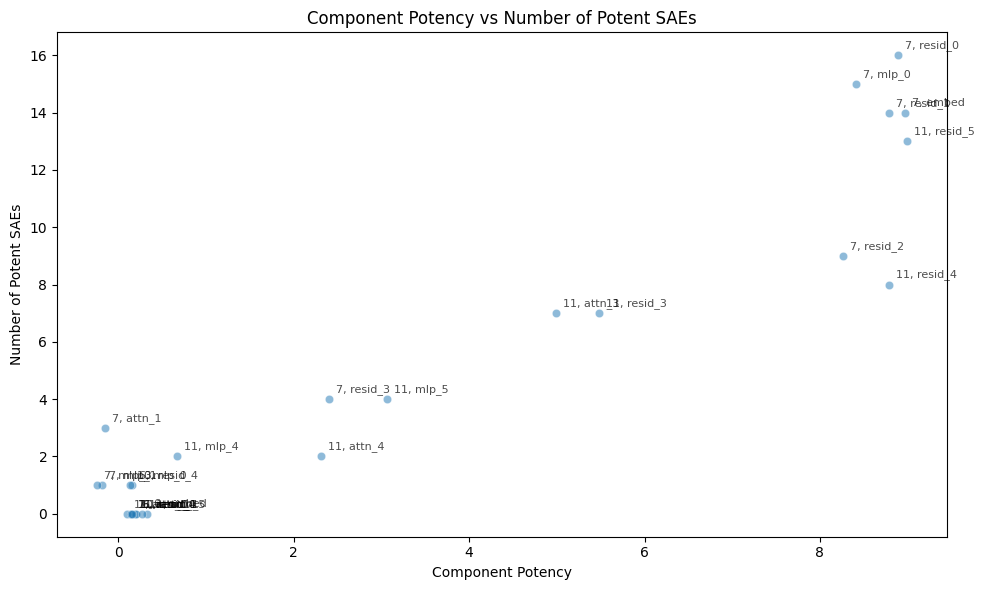

In [18]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and without treating resc as a component for all

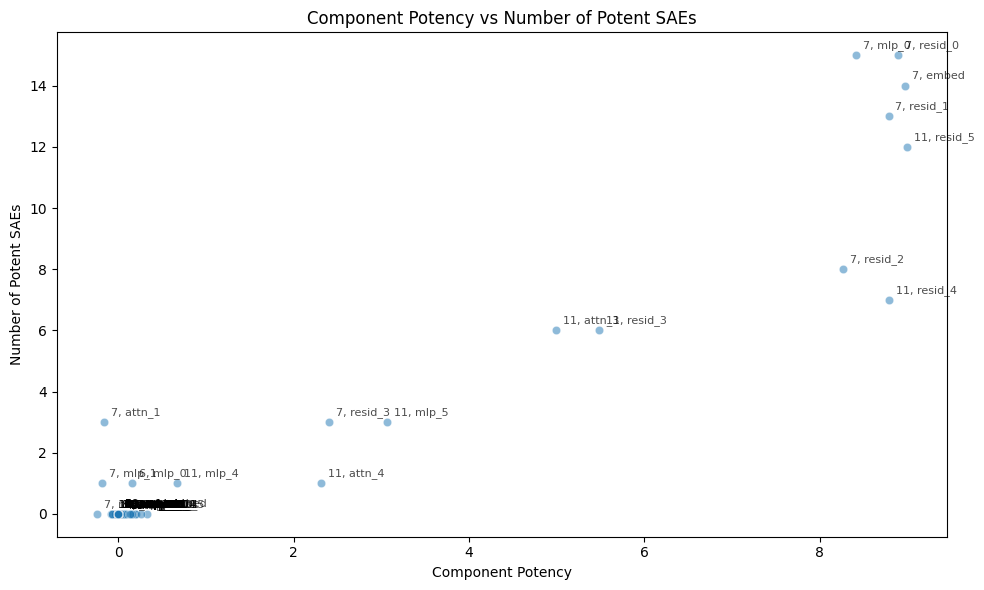

In [7]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and without treating resc as a component for selected

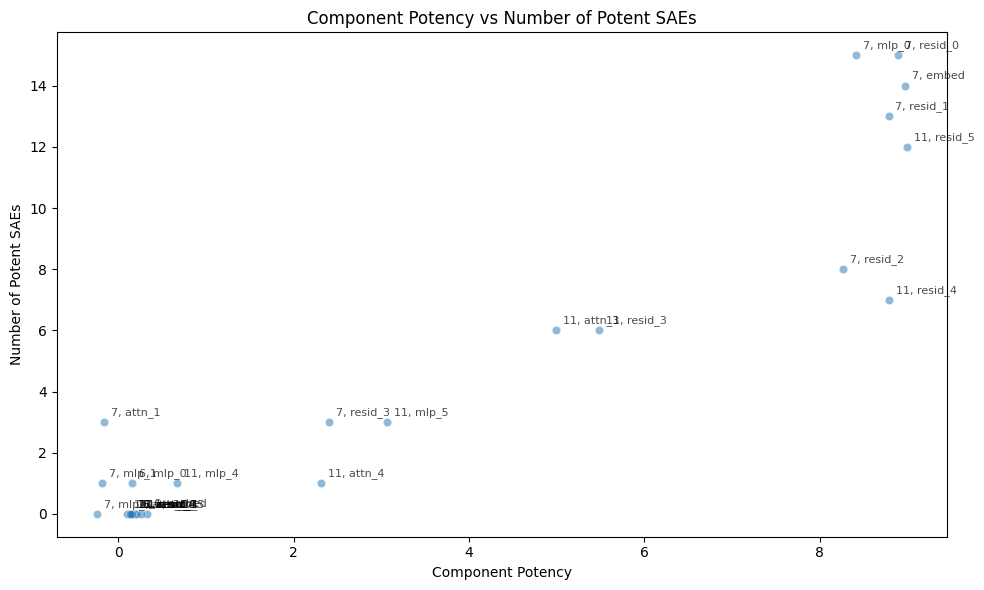

In [8]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### component vs potency of saes without treating resc as a node and using absolute value for all

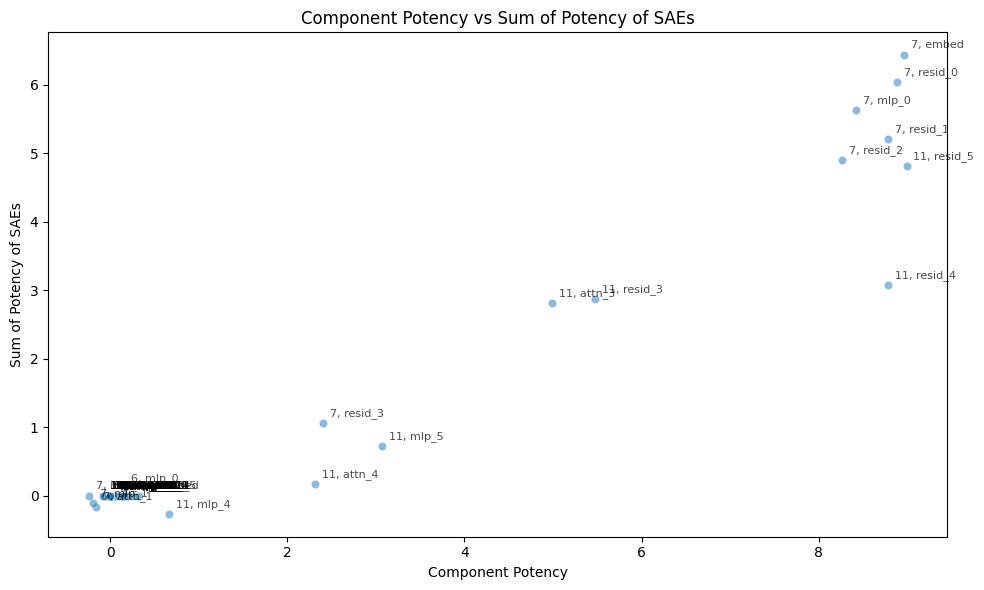

In [8]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### component vs potency of saes without treating resc as a node and using absolute value for selected

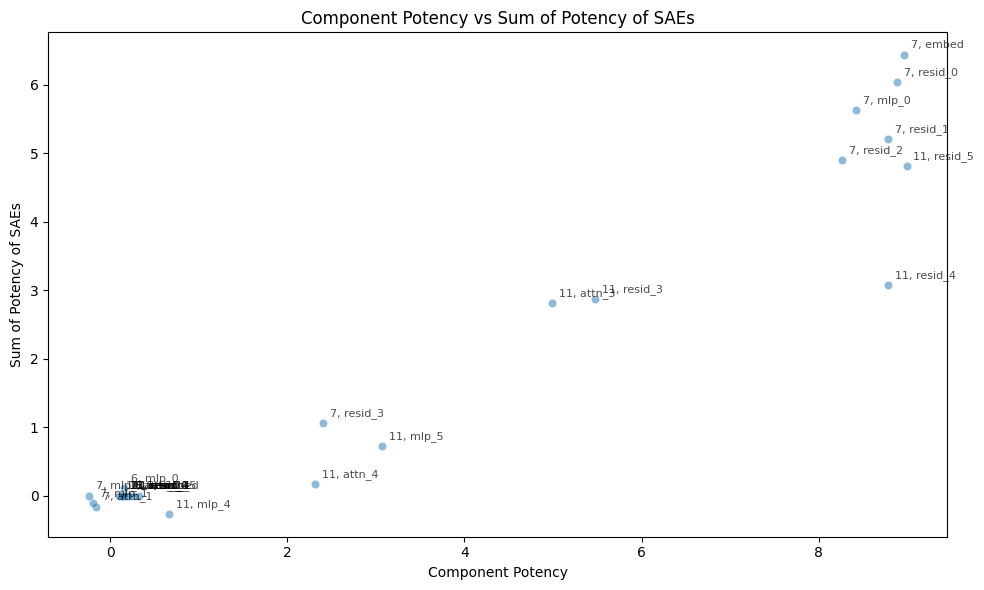

In [26]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

## Plotting ioi task

#### potency of saes with absolute value and treating resc as a component for all

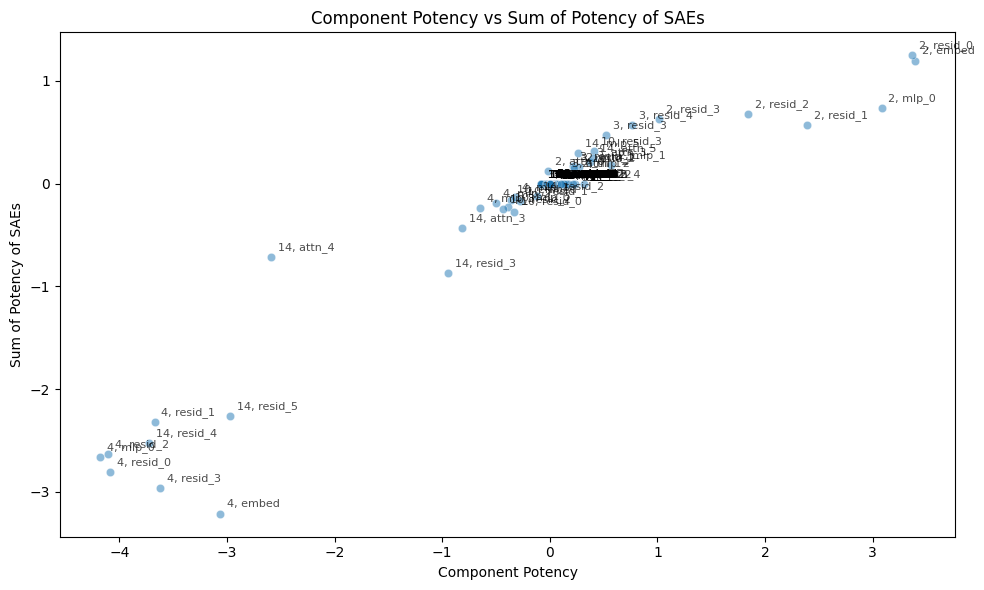

In [8]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### potency of saes with absolute value and treating resc as a component for selected

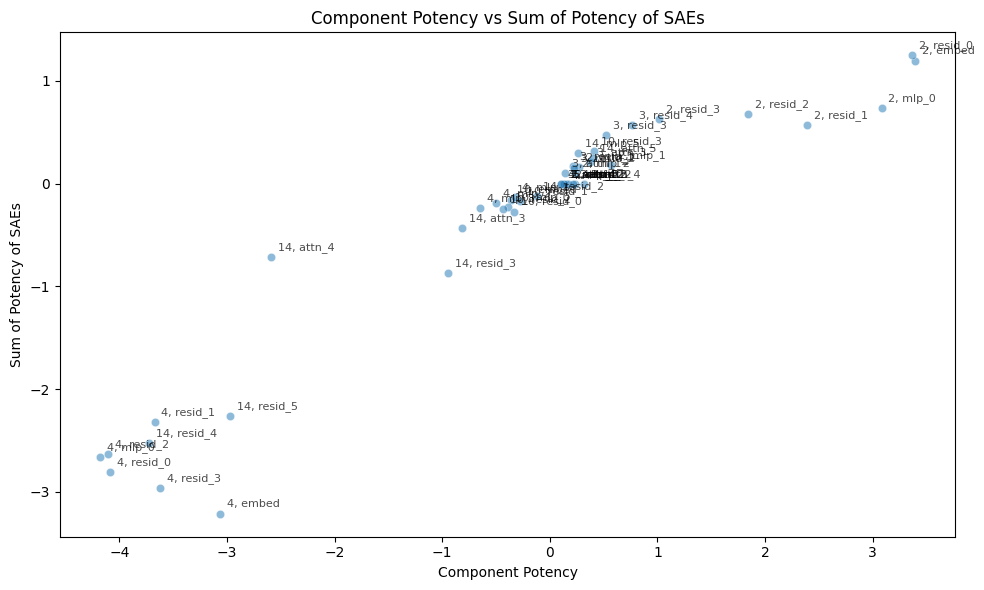

In [8]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and treating resc as a component for all

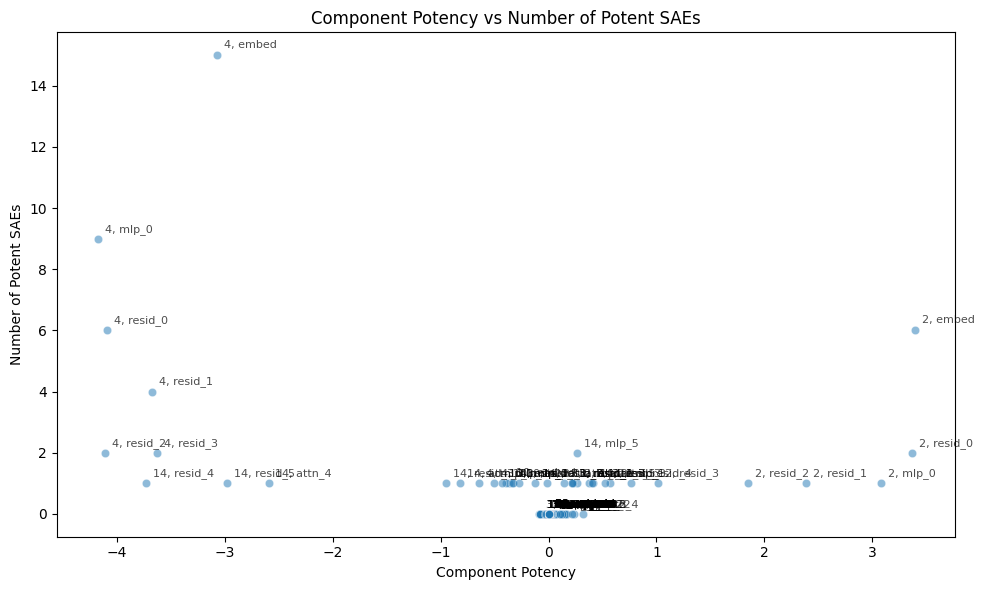

In [10]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
        
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and treating resc as a component for selected

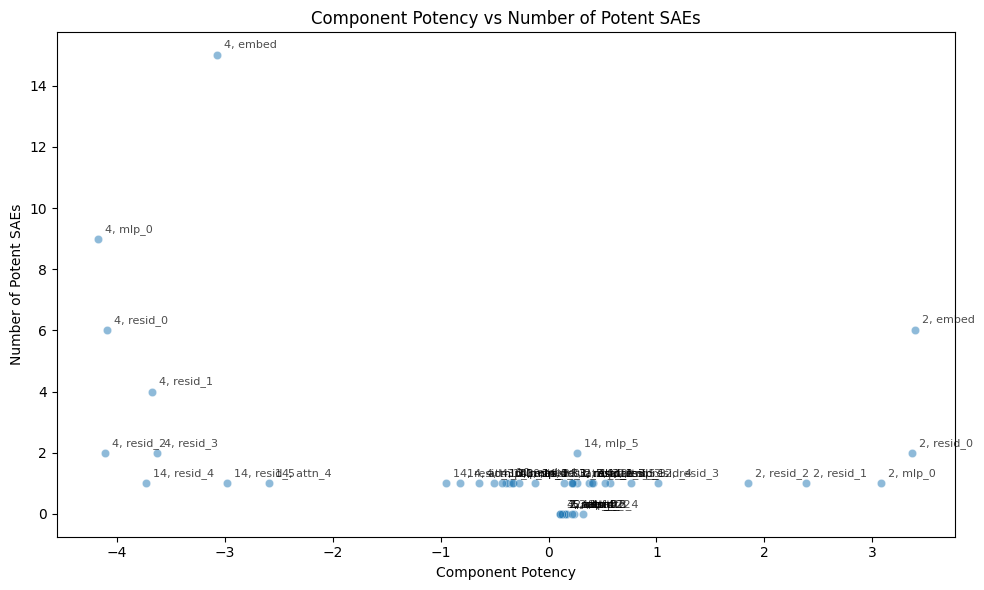

In [7]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and without treating resc as a component for all

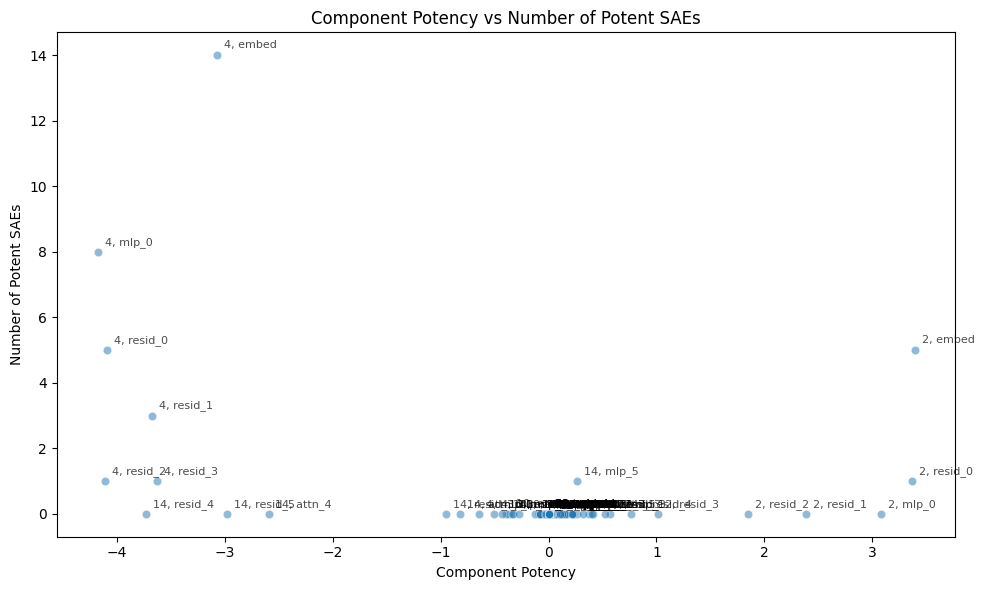

In [8]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### number of potent saes with absolute value and without treating resc as a component for selected

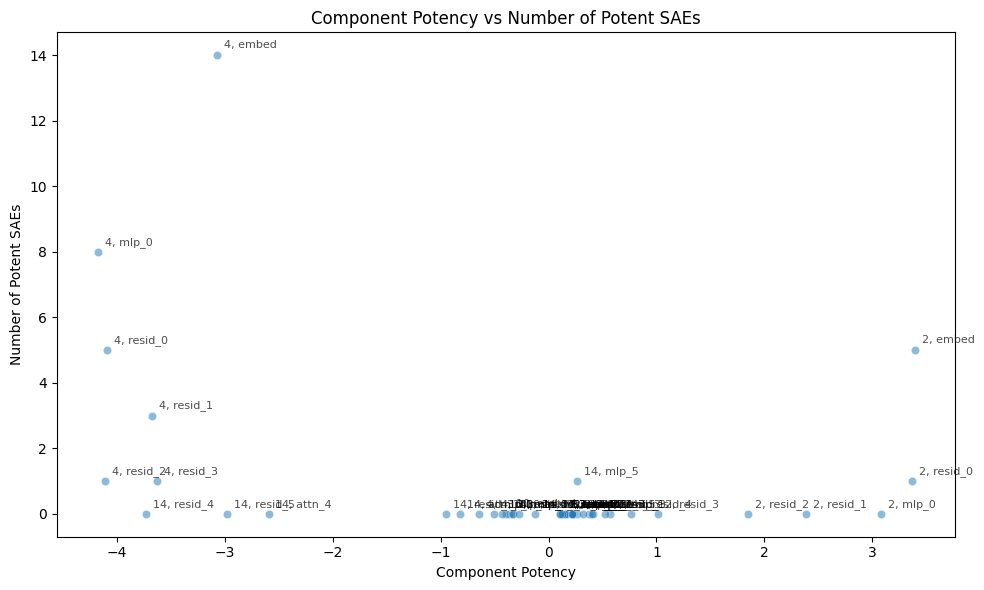

In [7]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### component vs potency of saes without treating resc as a node and using absolute value for all 

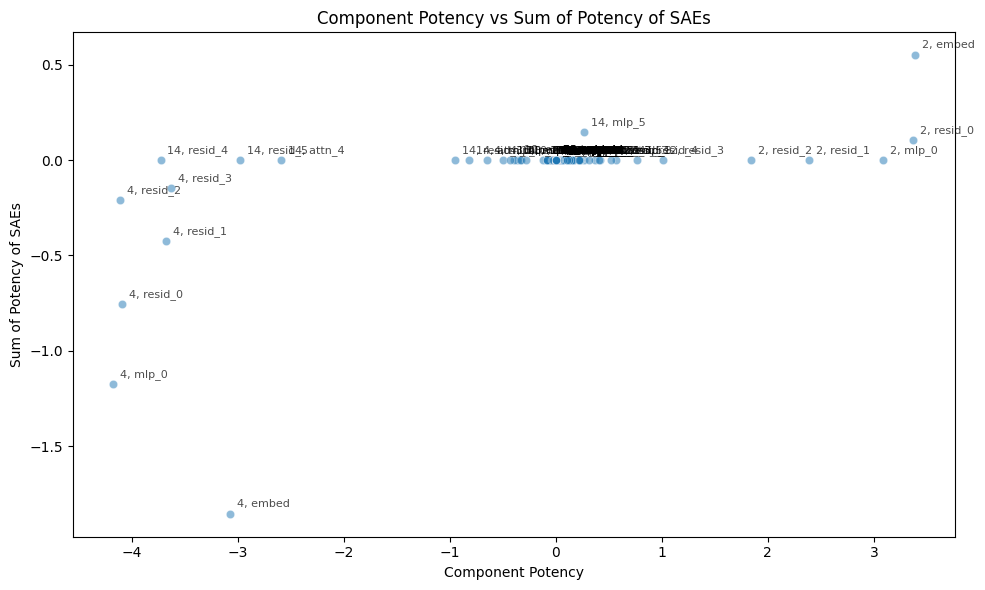

In [10]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### component vs potency of saes without treating resc as a node and using absolute value for selected

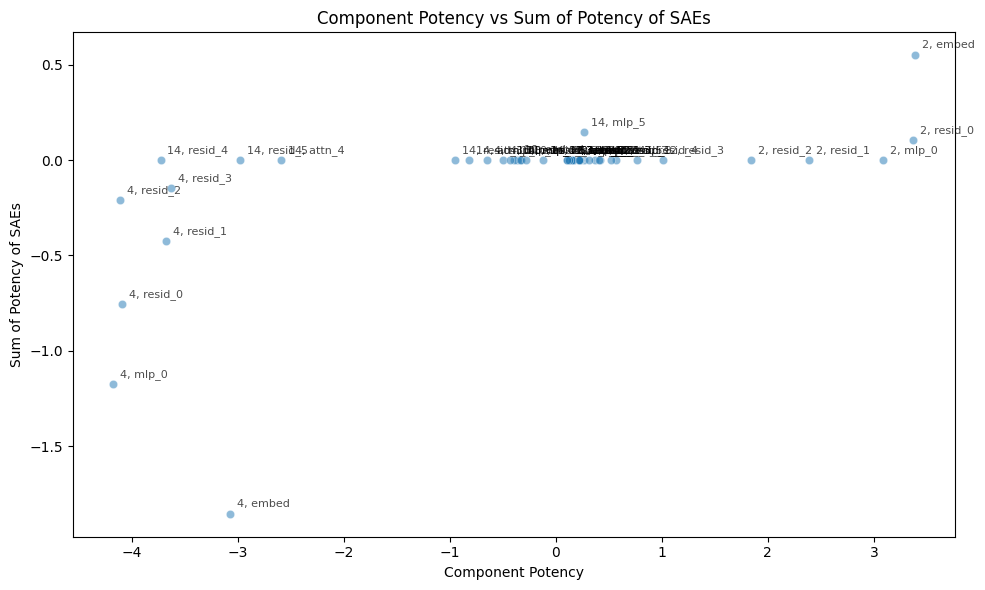

In [24]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Plots on RC clause

#### Plot of number of components for rc clause not considering abs value and not uniting resc for all

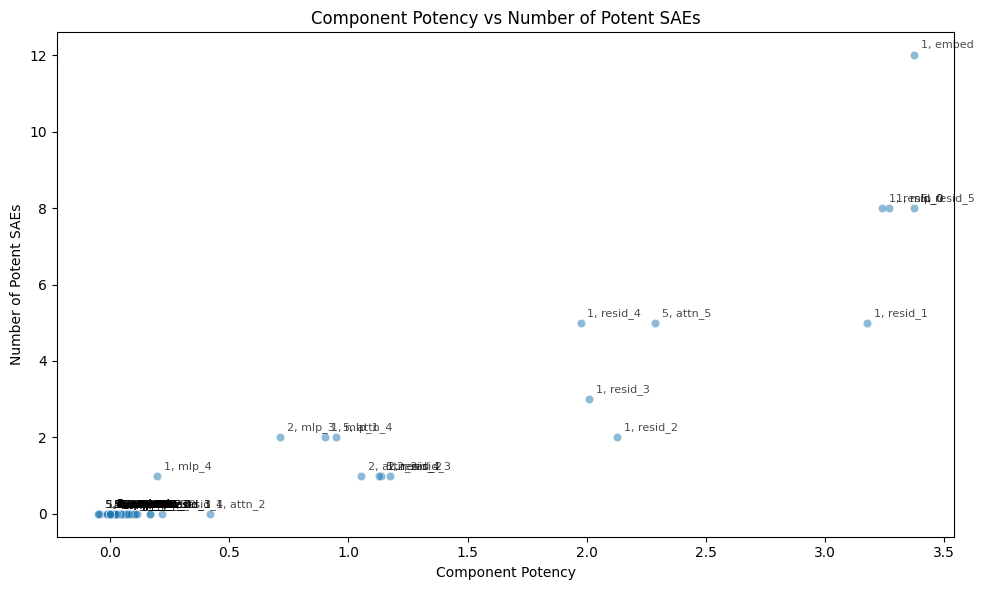

In [8]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of number of components for rc clause not considering abs value and not uniting resc for selected

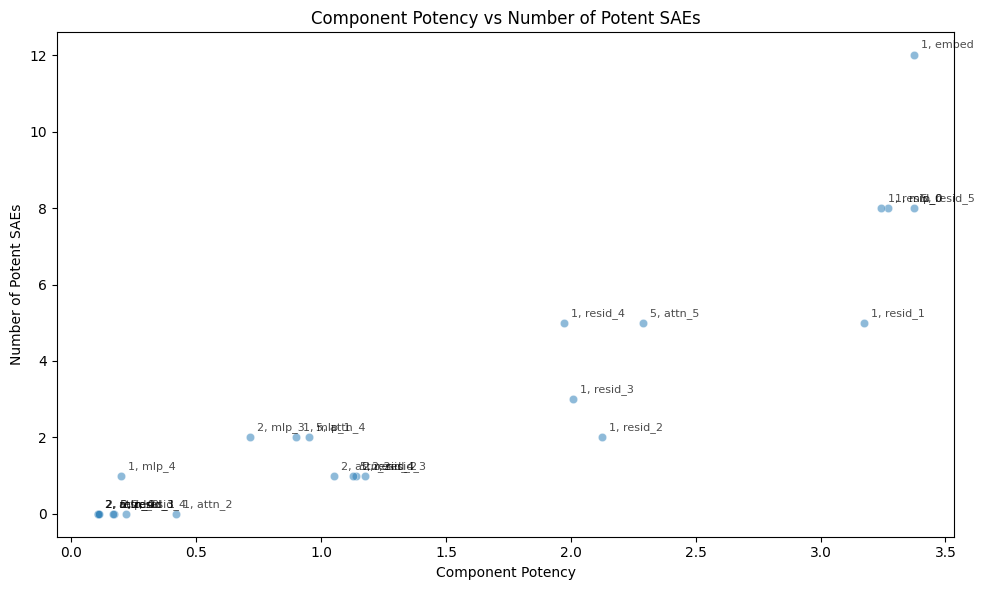

In [7]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of number of components for rc clause considering abs value and not uniting resc for all

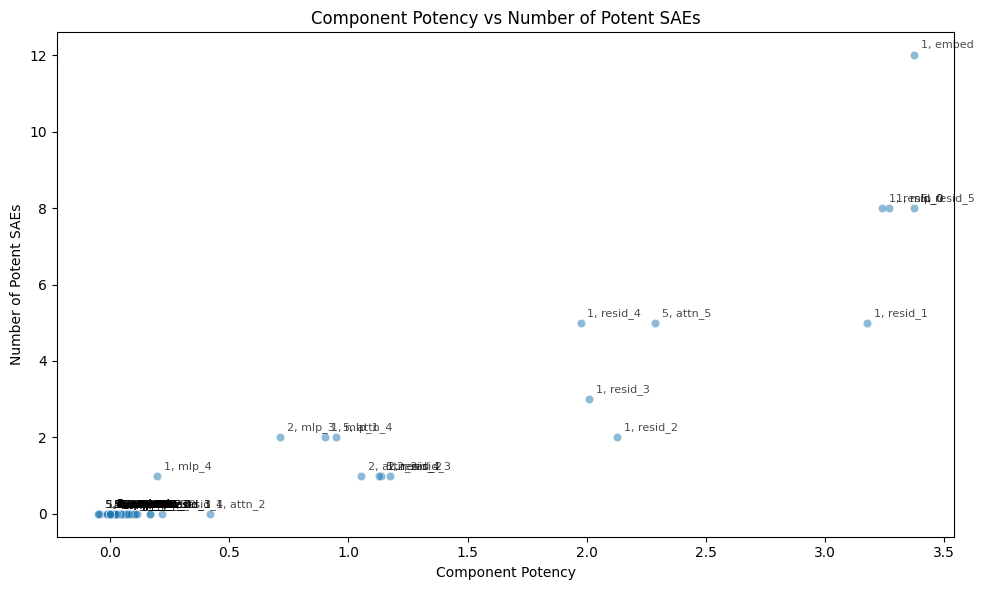

In [10]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of number of components for rc clause considering abs value and not uniting resc for selected

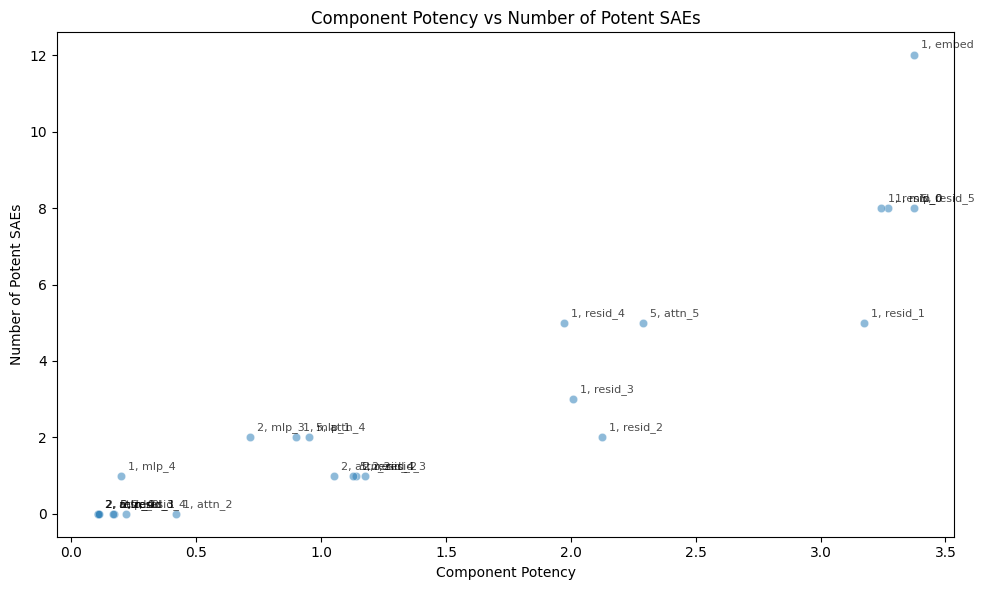

In [14]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of number of components for rc clause considering abs value and uniting resc and treat it as a node for all

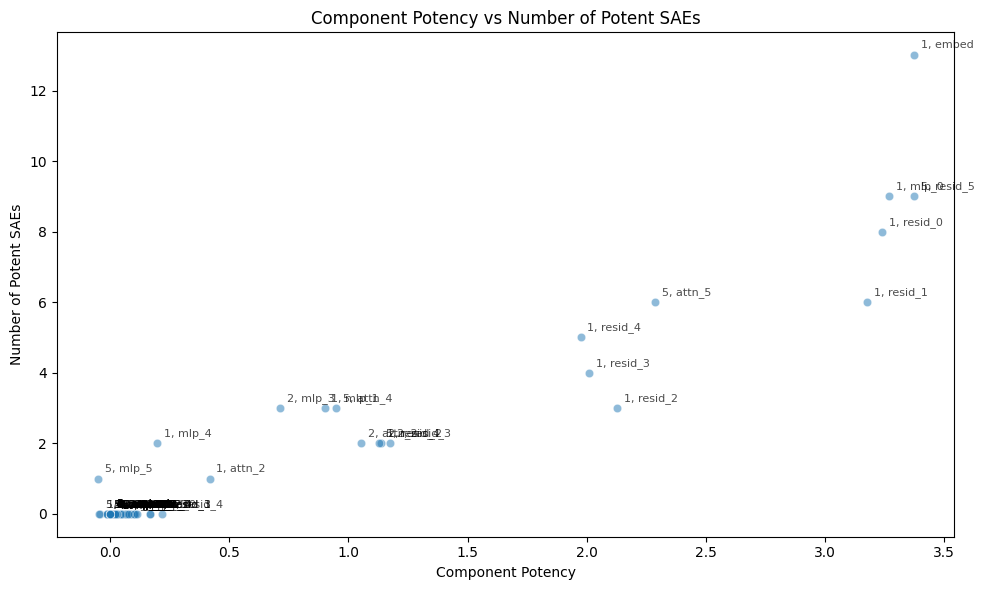

In [11]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of number of components for rc clause considering abs value and uniting resc and treat it as a node for selected

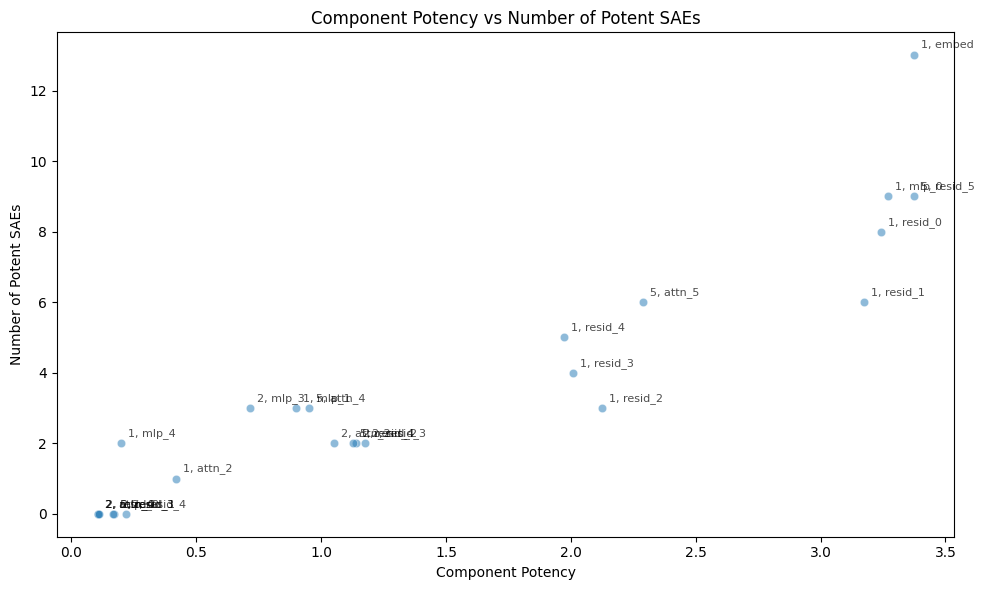

In [11]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = number_potent_saes[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Number of Potent SAEs')
plt.title('Component Potency vs Number of Potent SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of potency of components for rc clause considering abs value and uniting resc and treat it as a node for all

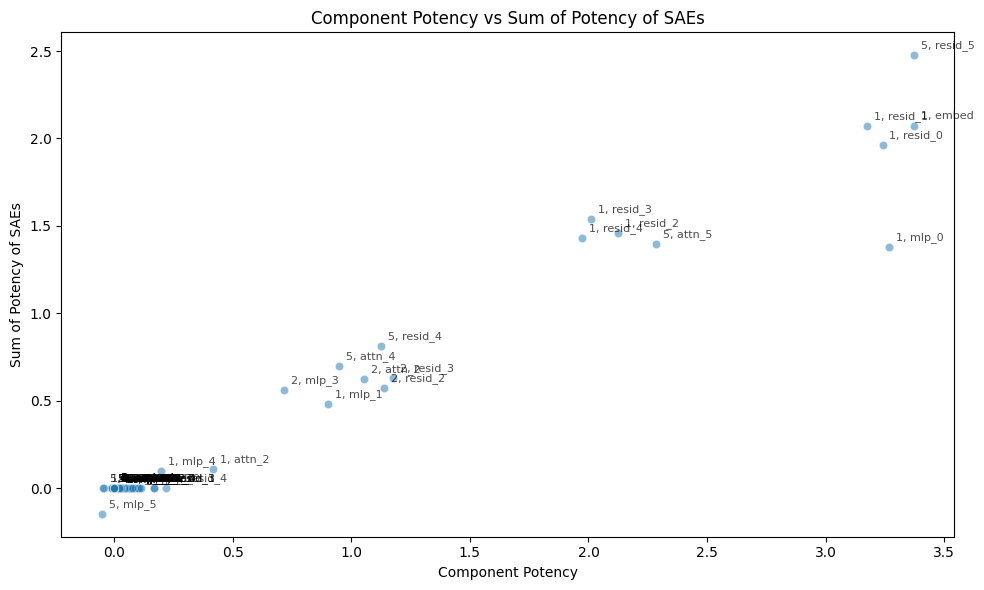

In [12]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of potency of components for rc clause considering abs value and uniting resc and treat it as a node for selected

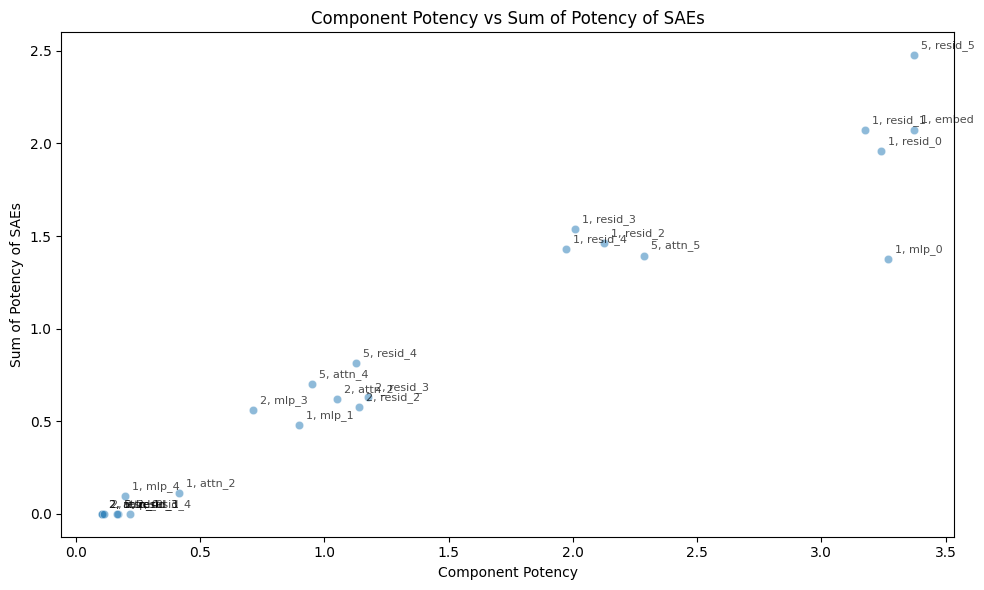

In [10]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of potency of components for rc clause considering abs value and without uniting resc and treat it as a node for all

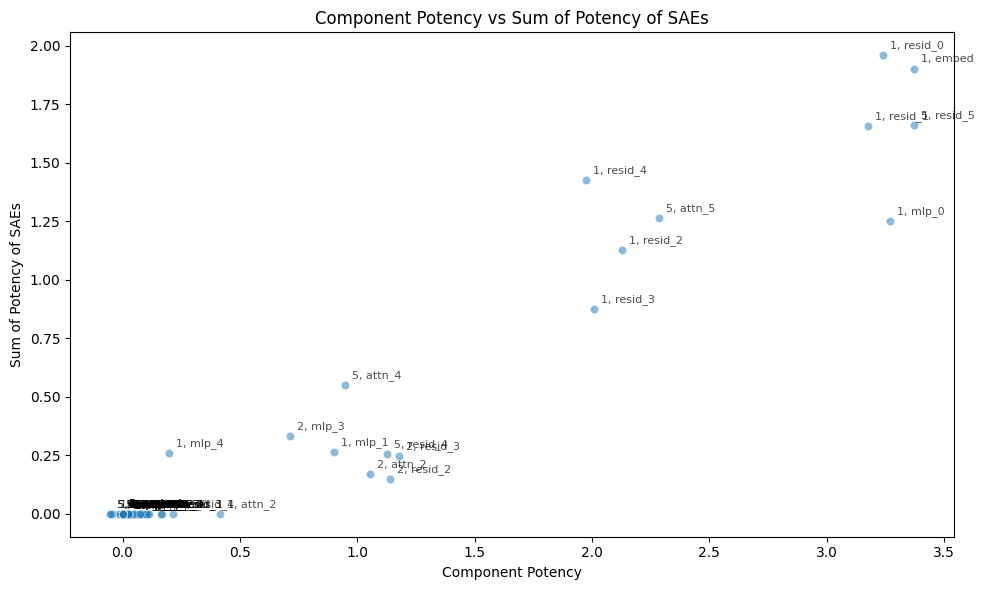

In [11]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of potency of components for rc clause considering abs value and without uniting resc and treat it as a node for selected

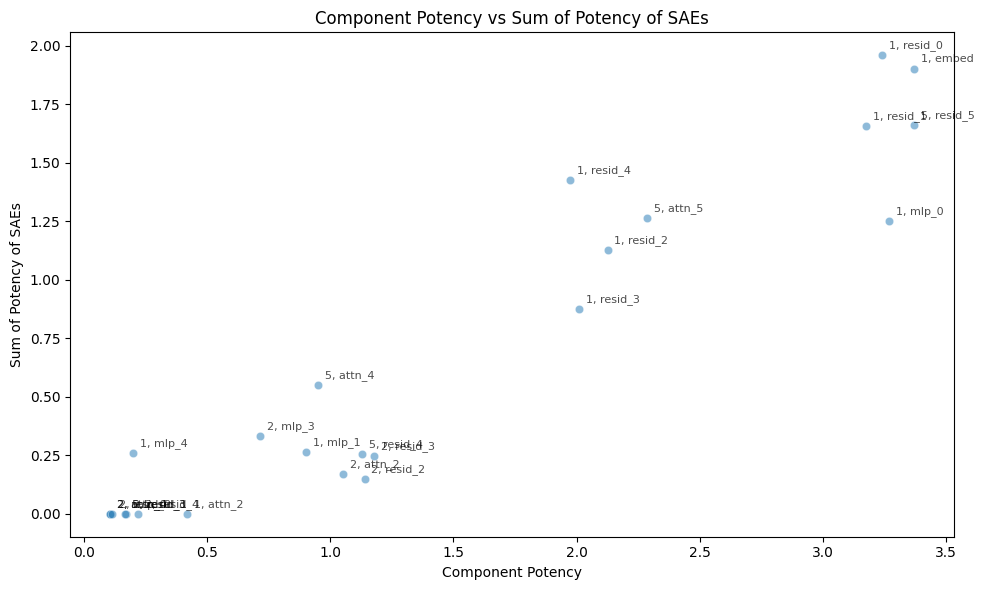

In [7]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act.abs() > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of potency of components for rc clause without considering abs value (only positive) and without uniting resc and treat it as a node for all

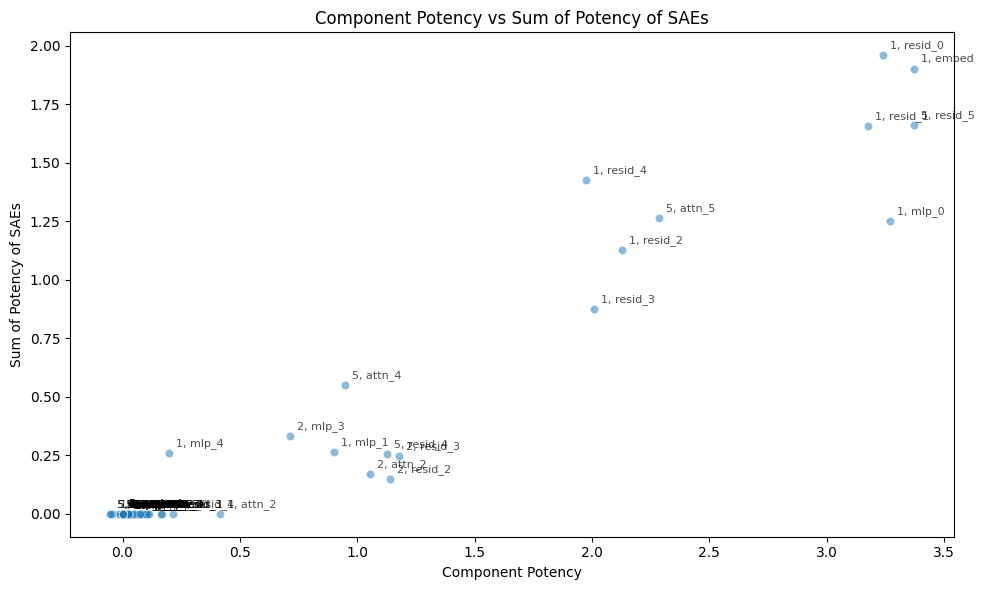

In [8]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.tensor(list(range(len(v.act)))).to('cuda:0')
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

#### Plot of potency of components for rc clause without considering abs value (only positive) and without uniting resc and treat it as a node for selected

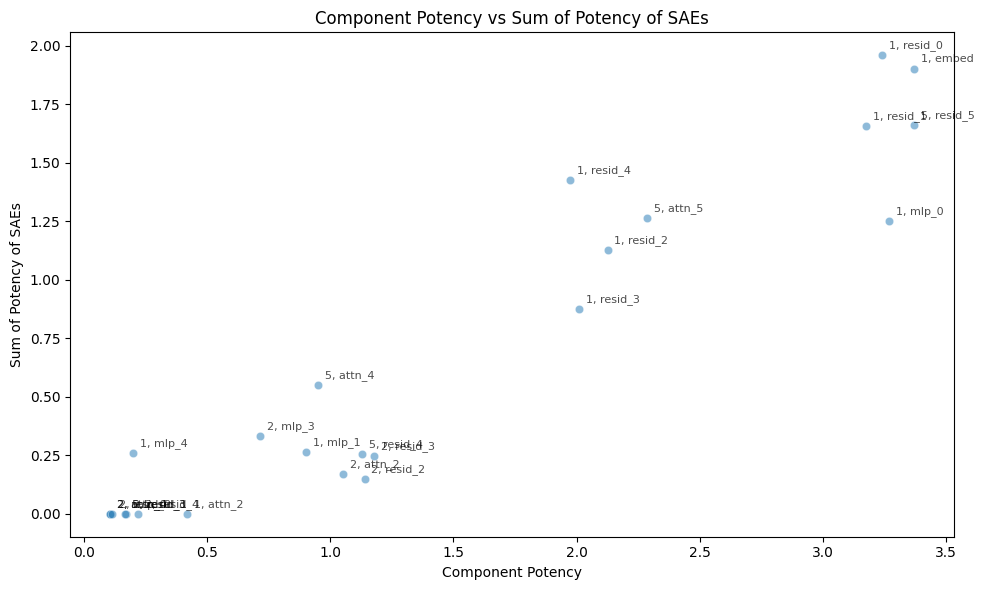

In [7]:
labels = []
x_values = []
y_values = []

for n, v in components_nodes.items():
    # Get the indices of components that are over the threshold
    indices = torch.where(v.act > THRESHOLD_COMPONENT)[0]
    
    new_labels = [f"{idx.item()}, {n}" for idx in indices]
    new_x = components_nodes[n].act[indices].tolist()
    new_y = sum_potency_sae[n][indices].tolist()
    
    # Extend the lists
    labels.extend(new_labels)
    x_values.extend(new_x)
    y_values.extend(new_y)

# Plotting the graph using seaborn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_values, y=y_values, alpha=0.5)
plt.xlabel('Component Potency')
plt.ylabel('Sum of Potency of SAEs')
plt.title('Component Potency vs Sum of Potency of SAEs')

# Add labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()